**Objective:**

We are merging 2 datasets of caltech and jpl. Then we are dealing with multiple `stationID` values occurring at the same `connectionTime` and checking outliers in the `KWhDelivered`, `total_charging_time`, and `idle_time` variables in this notebook. Also we applied smoothing technique (Croston TSB) for handling Intermittent demand

**Input**: `acn_caltech_0.2_0.1_with_stationID_22_06_2023.csv`, `acn_jpl_0.2_0.1_with_stationID_22_06_2023.csv`

**Output**: `acn_caltech_jpl_0.2_0.1_22_06_2023.csv`

**Reference**:`19/03/2023 caltech and JPL TCN w/o stationID part-2.ipynb`

# Mounting and Imports

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
import os
os.chdir("/content/drive/My Drive/TL_A/DeepKale/experiments_0.2/notebook/data_processing/base_model/")
!ls

19062023_caltech_data_preprocessing_with_stationID_part_1.ipynb
19062023_caltech_jpl_data_preprocessing_without_stationID_part_2.ipynb
19062023_jpl_data_preprocessing_with_stationID_part_1.ipynb


In [ ]:
import pandas as pd
import numpy as np
from scipy.interpolate import CubicSpline, interp1d
import scipy.stats as stats
import matplotlib.pyplot as plt
import plotly.express as px

SEED = 42
np.random.seed(SEED)

# Reading the CSVs

In [ ]:
df_caltech = pd.read_csv('../../../data/preprocessed/ACN/acn_caltech_0.2_0.1_with_stationID_22_06_2023.csv')
df_jpl = pd.read_csv('../../../data/preprocessed/ACN/acn_jpl_0.2_0.1_with_stationID_22_06_2023.csv')

In [ ]:
df_caltech.info()
df_jpl.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22345 entries, 0 to 22344
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   connectionTime       22345 non-null  object 
 1   kWhDelivered         22345 non-null  float64
 2   siteID               22345 non-null  int64  
 3   stationID            22345 non-null  int64  
 4   total_charging_time  22345 non-null  float64
 5   idle_time            22345 non-null  float64
dtypes: float64(3), int64(2), object(1)
memory usage: 1.0+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17740 entries, 0 to 17739
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   connectionTime       17740 non-null  object 
 1   kWhDelivered         17740 non-null  float64
 2   siteID               17740 non-null  int64  
 3   stationID            17740 non-null  int64  
 4   total_charging_ti

**Checking how many unique stationID is there for all the dataframes**

In [ ]:
# Total unique stationID of df_caltech
print("Total unique stationID in df_caltech:", df_caltech['stationID'].nunique())

# Total unique stationID of df_jpl
print("Total unique stationID in df_jpl:", df_jpl['stationID'].nunique())

Total unique stationID in df_caltech: 54
Total unique stationID in df_jpl: 52


**Checking if there is any common stationID between these two dataframes**

In [ ]:
common_station_ids = set(df_caltech['stationID']).intersection(set(df_jpl['stationID']))
if len(common_station_ids) > 0:
    print("There is at least one common stationID between the two dataframes.")
else:
    print("There are no common stationIDs between the two dataframes.")

There are no common stationIDs between the two dataframes.


In [ ]:
df_caltech_common = df_caltech[df_caltech['stationID'].isin(df_jpl['stationID'])]
df_jpl_common = df_jpl[df_jpl['stationID'].isin(df_caltech['stationID'])]

In [ ]:
df_caltech_common

,connectionTime,kWhDelivered,siteID,stationID,total_charging_time,idle_time


In [ ]:
df_jpl_common

,connectionTime,kWhDelivered,siteID,stationID,total_charging_time,idle_time


**Merging the Two dataframes into one dataframe**

In [ ]:
# Merge the two dataframes
final_df = pd.concat([df_caltech, df_jpl])

final_df['connectionTime'] = pd.to_datetime(final_df['connectionTime'])

In [ ]:
final_df = final_df.sort_values('connectionTime').reset_index(drop=True)

In [ ]:
final_df.describe()

,kWhDelivered,siteID,stationID,total_charging_time,idle_time
count,40085.000000,40085.000000,40085.000000,40085.000000,40085.000000
mean,9.203117,1.557440,111780.478907,2.927522,2.956016
std,6.215306,0.496696,73304.453454,1.873178,2.782545
min,0.501000,1.000000,8824.000000,0.001667,0.000278
25%,4.718000,1.000000,13928.000000,1.493611,0.171944
50%,8.011000,2.000000,92436.000000,2.462778,2.297778
75%,12.900000,2.000000,179815.000000,4.053333,5.298056
max,36.629000,2.000000,194826.000000,9.542778,11.927500


In [ ]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40085 entries, 0 to 40084
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   connectionTime       40085 non-null  datetime64[ns]
 1   kWhDelivered         40085 non-null  float64       
 2   siteID               40085 non-null  int64         
 3   stationID            40085 non-null  int64         
 4   total_charging_time  40085 non-null  float64       
 5   idle_time            40085 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(2)
memory usage: 1.8 MB


In [ ]:
final_df.head(15)

,connectionTime,kWhDelivered,siteID,stationID,total_charging_time,idle_time
0,2018-04-25 06:45:10,10.013,2,9527,2.984722,8.200278
1,2018-04-25 06:45:50,5.257,2,79380,1.098333,8.216944
2,2018-04-25 07:37:06,5.177,2,79379,1.471111,7.836667
3,2018-04-25 07:40:34,10.119,2,79381,2.998889,5.378333
4,2018-04-25 07:43:50,7.910,2,13928,1.577222,8.983889
5,2018-04-25 07:47:42,15.294,2,91441,3.666667,0.002500
6,2018-04-25 07:58:25,6.953,2,79377,1.834444,2.300000
7,2018-04-25 08:10:52,2.174,2,79382,0.951111,2.130556
8,2018-04-25 08:14:06,6.955,2,78366,3.320556,0.002778
9,2018-04-25 08:14:49,2.720,2,78361,1.453056,7.180556


# Addressing duplicacy issue in `connectionTime`

**Now after merging again checking if both of the dataframes have common `connectionTime`**

In [ ]:
# Find the duplicated rows based on the 'connectionTime' column
duplicated_df = final_df[final_df.duplicated(subset=['connectionTime'], keep=False)]

# Print the new DataFrame
duplicated_df

,connectionTime,kWhDelivered,siteID,stationID,total_charging_time,idle_time
9583,2018-10-10 07:56:13,11.142000,2,124558,3.845278,7.963611
9584,2018-10-10 07:56:13,5.629000,1,179813,1.900000,9.841111
10528,2018-10-19 08:32:10,8.894000,2,79381,3.088889,8.023611
10529,2018-10-19 08:32:10,12.531411,1,191782,4.102500,6.159167
11591,2018-10-30 08:37:23,8.011000,1,191807,2.468056,2.138056
11592,2018-10-30 08:37:23,6.973478,2,78365,3.562500,0.593333
13270,2018-11-20 13:26:49,19.782000,1,179783,3.155278,0.489444
13271,2018-11-20 13:26:49,0.939000,2,12818,0.226111,0.588611
13801,2018-11-30 07:17:22,10.157000,1,179783,5.395278,1.617222
13802,2018-11-30 07:17:22,0.903000,2,78366,6.151389,0.488056


**20 duplicates. We need to handle them**

In [ ]:
len(duplicated_df)

20

**The unique hours that we have duplicacy**

In [ ]:
unique_hours = duplicated_df['connectionTime'].dt.hour.unique()
unique_hours

array([ 7,  8, 13,  6, 10])

**At the given duplicate hours we are finding out the maximum occuring `stationID`for the whole time period.**

In [ ]:
df = final_df.copy()
# First, make sure the connectionTime column is a datetime type
df['connectionTime'] = pd.to_datetime(df['connectionTime'])

# Extract the hour from the connectionTime column
df['hour'] = df['connectionTime'].dt.hour

# Then, filter the DataFrame to only include rows with the hours of interest
df_filtered = df[df['hour'].isin(unique_hours)]

# Group the filtered DataFrame by hour and stationID, and count the occurrences of each
grouped = df_filtered.groupby(['hour', 'stationID']).size()

# Get the stationID with the highest count for each hour of interest
for hour in unique_hours:
    max_station = grouped[hour].idxmax()
    print(f"At hour {hour}, stationID {max_station} had the highest count.")

At hour 7, stationID 191782 had the highest count.
At hour 8, stationID 13130 had the highest count.
At hour 13, stationID 13928 had the highest count.
At hour 6, stationID 193820 had the highest count.
At hour 10, stationID 12422 had the highest count.


**Also sorting the occurance of `stationID` from highest to lowest for a particular hour (obviously duplicated unique hours)**

In [ ]:
unique_hours = duplicated_df['connectionTime'].dt.hour.unique()

df = final_df.copy()
df['connectionTime'] = pd.to_datetime(df['connectionTime'])
df['hour'] = df['connectionTime'].dt.hour
df_filtered = df[df['hour'].isin(unique_hours)]

grouped = df_filtered.groupby(['hour', 'stationID']).size().reset_index(name='count')

for hour in unique_hours:
    hour_df = grouped[grouped['hour'] == hour].sort_values('count', ascending=False)
    print(f"At hour {hour}, the occurrences of stationID from highest to lowest are:")
    for index, row in hour_df.iterrows():
        print(f"{row['stationID']}: {row['count']} occurrences")

At hour 7, the occurrences of stationID from highest to lowest are:
191782: 229 occurrences
191805: 222 occurrences
191792: 213 occurrences
191807: 207 occurrences
191780: 206 occurrences
191812: 199 occurrences
191806: 195 occurrences
191778: 185 occurrences
179779: 181 occurrences
191795: 174 occurrences
191811: 173 occurrences
179798: 171 occurrences
179790: 171 occurrences
191808: 170 occurrences
191793: 160 occurrences
191786: 159 occurrences
179813: 158 occurrences
191784: 153 occurrences
191785: 151 occurrences
191803: 148 occurrences
179801: 148 occurrences
179794: 138 occurrences
191802: 137 occurrences
179809: 126 occurrences
179777: 121 occurrences
191804: 112 occurrences
179783: 111 occurrences
179788: 109 occurrences
179791: 103 occurrences
179787: 100 occurrences
179781: 94 occurrences
179797: 81 occurrences
13928: 80 occurrences
78366: 79 occurrences
179815: 78 occurrences
79382: 66 occurrences
179796: 66 occurrences
179800: 59 occurrences
79381: 55 occurrences
13829: 55

**The duplicates for stationID at the same time are handled by selecting the stationID with the highest count for each hour (if available). If no such stationID is found, random rows are selected to ensure a minimum number of samples (n_samples) for that hour.**

In [ ]:
# First, extract the hour from the connectionTime column
duplicated_df = duplicated_df.assign(hour=duplicated_df['connectionTime'].dt.hour)

# Filter the DataFrame to only include rows with the hours of interest
df_filtered = duplicated_df[duplicated_df['hour'].isin(unique_hours)]

n_samples = 1
# For each hour of interest, identify the stationID with the highest count and keep only the rows with that stationID
for hour in unique_hours:
    # Filter the DataFrame to only include rows for the current hour
    df_hour = df_filtered[df_filtered['hour'] == hour]
    # Group the DataFrame by stationID and count the occurrences of each
    grouped = df_hour.groupby('stationID').size().reset_index(name='count')
    # Sort the DataFrame by count in descending order
    grouped.sort_values('count', ascending=False, inplace=True)

    # Find the stationID with the highest count that is not already selected for this hour
    selected_stationID = None
    for stationID in grouped['stationID']:
        if not df_filtered[(df_filtered['hour'] == hour) & (df_filtered['stationID'] == stationID)].empty:
            selected_stationID = stationID
            break

    if selected_stationID is None:
        # If no stationID is found, pick random rows from the duplicated_df for this hour
        df_selected = df_filtered[df_filtered['hour'] == hour].sample(n=min(n_samples, len(df_filtered[df_filtered['hour'] == hour])), random_state=SEED)
    else:
        # Keep only the rows with the selected stationID for this hour
        df_selected = df_filtered[(df_filtered['hour'] != hour) | (df_filtered['stationID'] == selected_stationID)]

    # Add the selected rows to the final DataFrame
    if hour == unique_hours[0]:
        df_final = df_selected
    else:
        df_final = pd.concat([df_final, df_selected])

# Finally, remove duplicates based on connectionTime
df_final.drop_duplicates(subset='connectionTime', inplace=True)

In [ ]:
df_final.shape

(10, 7)

In [ ]:
final_df.shape

(40085, 6)

In [ ]:
final_df.drop_duplicates(subset=['connectionTime'], keep=False, inplace=True)

In [ ]:
final_df.shape

(40065, 6)

In [ ]:
duplicates = final_df.duplicated(subset='connectionTime')
if duplicates.any():
    print('There are duplicates based on the connectionTime column.')
else:
    print('There are no duplicates based on the connectionTime column.')

There are no duplicates based on the connectionTime column.


In [ ]:
final_df = pd.concat([final_df, df_final], ignore_index=True)
final_df.shape

(40075, 7)

**Finally done! 😊**

In [ ]:
duplicates = final_df.duplicated(subset='connectionTime')
if duplicates.any():
    print('There are duplicates based on the connectionTime column.')
else:
    print('There are no duplicates based on the connectionTime column.')

There are no duplicates based on the connectionTime column.


In [ ]:
# Drop the 'hour' column from the dataframe
final_df.drop('hour', axis=1, inplace=True)

# Some visualization

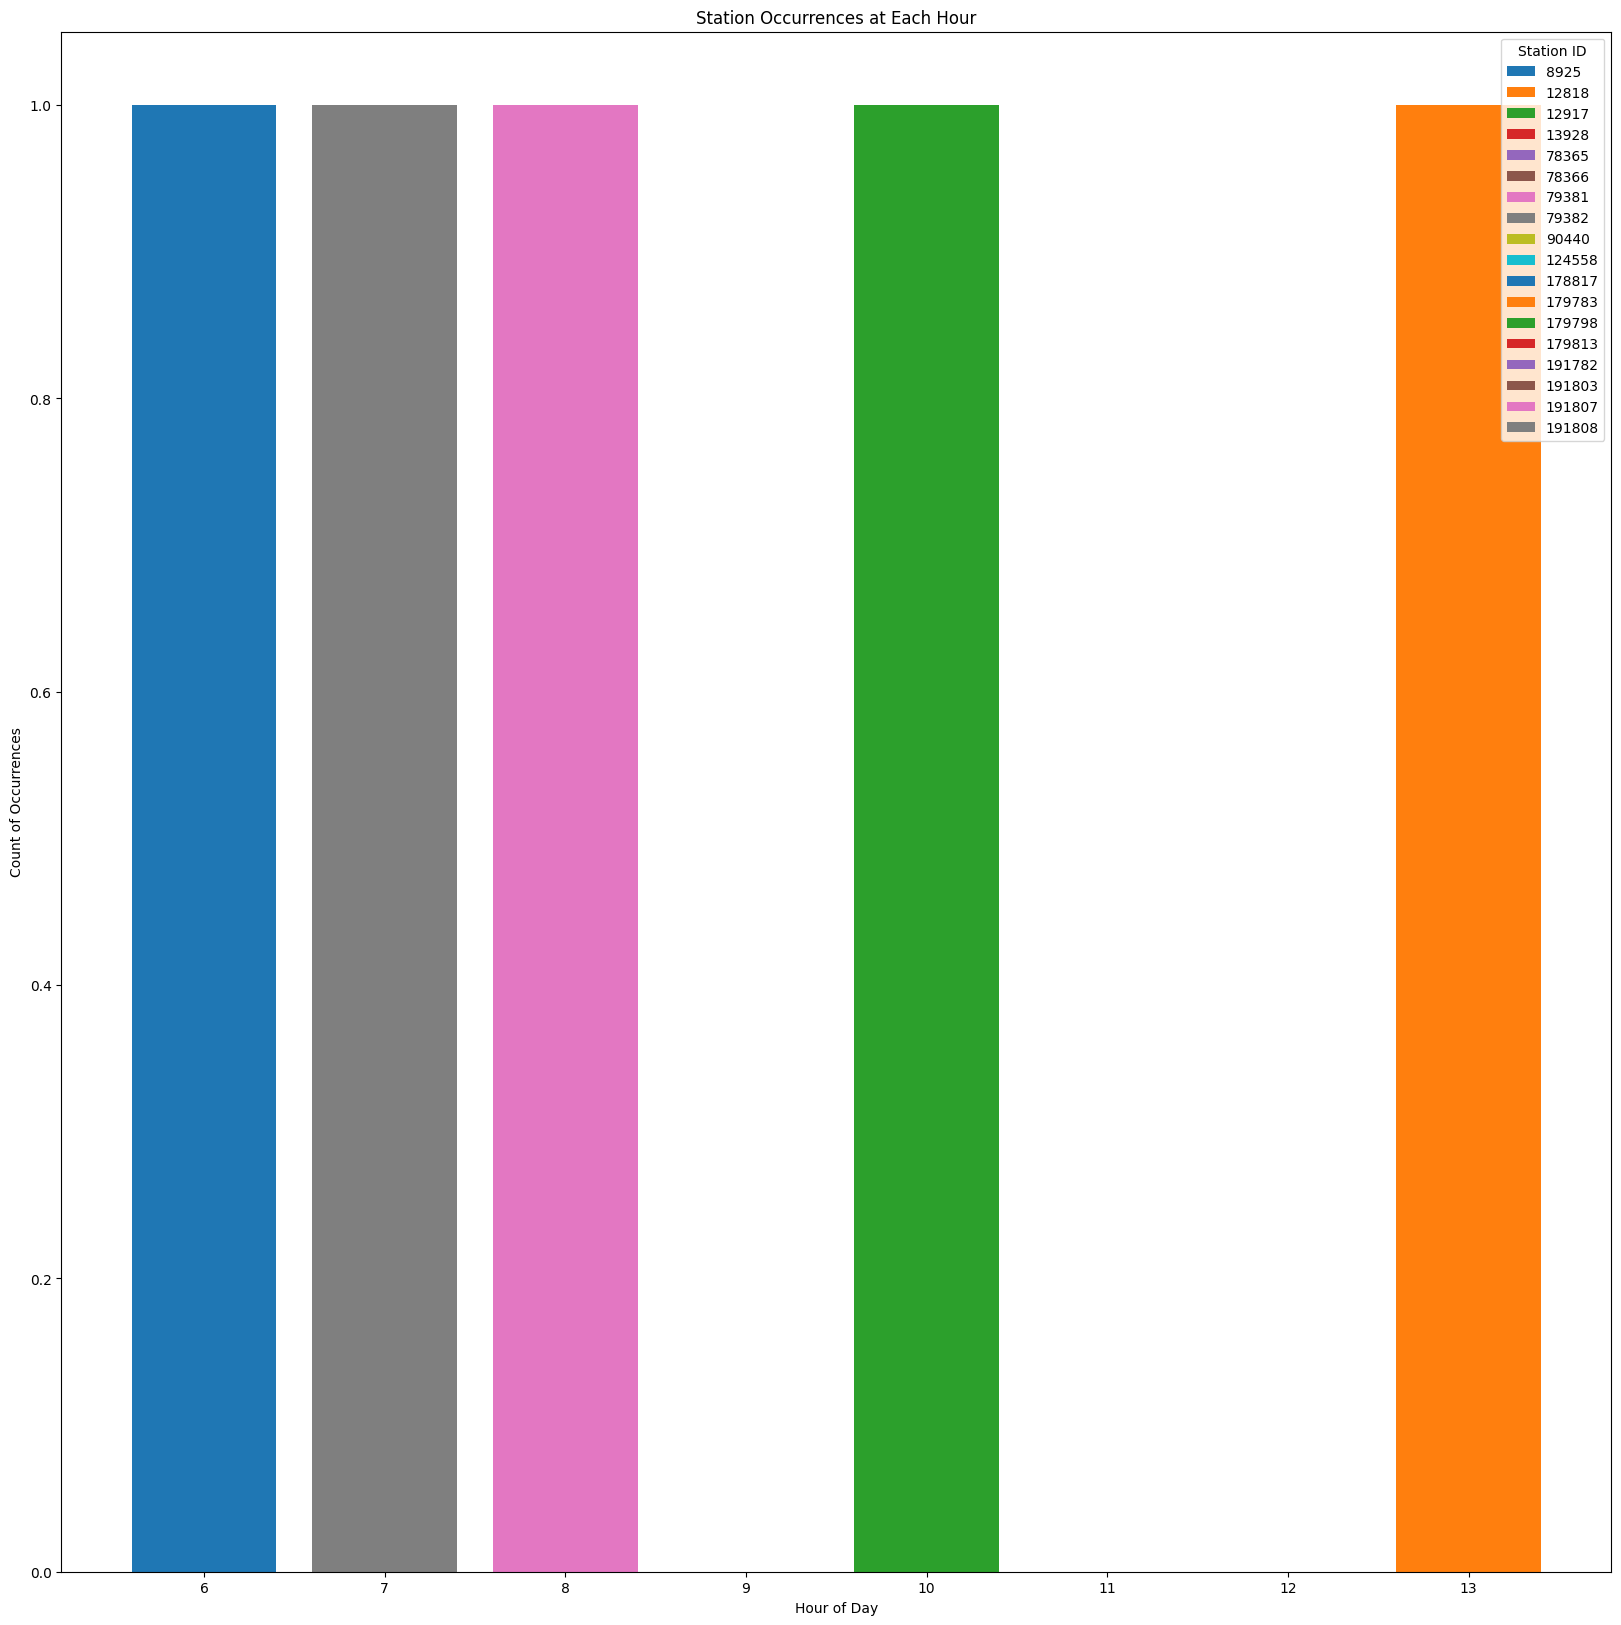

In [ ]:
import matplotlib.pyplot as plt

# Group the filtered DataFrame by hour and stationID, and count the occurrences of each
grouped = df_filtered.groupby(['hour', 'stationID']).size().reset_index(name='count')

# Plot a histogram of the station occurrences at each hour
fig, ax = plt.subplots(figsize=(20, 20))
for name, group in grouped.groupby('stationID'):
    ax.bar(group['hour'], group['count'], label=name)

# Add labels and legend
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Count of Occurrences')
ax.set_title('Station Occurrences at Each Hour')
ax.legend(title='Station ID')
plt.show()

**Considering data before Covid. date: 15-03-2020. After this date there is a sharp drop**

In [ ]:
final_df_before_COVID = final_df.loc[final_df['connectionTime'] < pd.to_datetime('2020-03-15')]
final_df_before_COVID.shape

(40075, 6)

In [ ]:
final_df_before_COVID.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 40075 entries, 0 to 40074
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   connectionTime       40075 non-null  datetime64[ns]
 1   kWhDelivered         40075 non-null  float64       
 2   siteID               40075 non-null  int64         
 3   stationID            40075 non-null  int64         
 4   total_charging_time  40075 non-null  float64       
 5   idle_time            40075 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(2)
memory usage: 2.1 MB


# Make hourly samples

For hourly samples we have 57% available data and 43% missing data

In [ ]:
df_H = final_df_before_COVID.copy()

# Convert the 'connectionTime' column to datetime and set it as the index
df_H.set_index('connectionTime', inplace=True)

# Resample the DataFrame to hourly frequency and count the number of missing values
df_H = df_H.resample('H').mean()  # use 'mean' or another method to aggregate the 'kWhDelivered' values
num_missing = df_H['kWhDelivered'].isna().sum()

# Calculate the percentage of available and missing data
total_hours = len(df_H)
pct_available = (total_hours - num_missing) / total_hours * 100
pct_missing = num_missing / total_hours * 100

print(f'Percentage of available data: {pct_available:.2f}%')
print(f'Percentage of missing data: {pct_missing:.2f}%')

Percentage of available data: 57.20%
Percentage of missing data: 42.80%


**We have total 689 days and within this time we will have 16.5k samples**

In [ ]:
import pandas as pd
start_time = pd.to_datetime('2018-04-25 06:45:10')
end_time = pd.to_datetime('2020-03-14 22:58:50')
time_diff = end_time - start_time
print(time_diff)

689 days 16:13:40


In [ ]:
num_points = int(time_diff.total_seconds() / (1 * 60 * 60)) + 1
print(num_points)

16553


In [ ]:
final_df_before_COVID

,connectionTime,kWhDelivered,siteID,stationID,total_charging_time,idle_time
0,2018-04-25 06:45:10,10.013,2,9527,2.984722,8.200278
1,2018-04-25 06:45:50,5.257,2,79380,1.098333,8.216944
2,2018-04-25 07:37:06,5.177,2,79379,1.471111,7.836667
3,2018-04-25 07:40:34,10.119,2,79381,2.998889,5.378333
4,2018-04-25 07:43:50,7.910,2,13928,1.577222,8.983889
...,...,...,...,...,...,...
40070,2020-01-31 10:35:40,0.933,2,90440,5.835556,0.179444
40071,2020-02-26 07:41:40,6.330,2,12917,1.039722,0.001389
40072,2018-10-10 07:56:13,11.142,2,124558,3.845278,7.963611
40073,2018-11-30 07:17:22,10.157,1,179783,5.395278,1.617222


In [ ]:
final_df_before_COVID.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 40075 entries, 0 to 40074
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   connectionTime       40075 non-null  datetime64[ns]
 1   kWhDelivered         40075 non-null  float64       
 2   siteID               40075 non-null  int64         
 3   stationID            40075 non-null  int64         
 4   total_charging_time  40075 non-null  float64       
 5   idle_time            40075 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(2)
memory usage: 2.1 MB


# Handling features `siteID` and `stationID` for the same `connectionTime`

**We perform grouping, aggregation, merging, renaming, and data cleaning operations to transform the original DataFrame into a new DataFrame final_df_before_COVID_hourly with hourly aggregated data, mean values, and replaced missing values.**

In [ ]:
# Group by hourly timestamps and concatenate station IDs and site IDs with underscores
final_df_before_COVID_hourly = final_df_before_COVID.groupby(pd.Grouper(key='connectionTime', freq='1H')) \
    .agg({'stationID': lambda x: '_'.join(x.unique().astype(str)),
          'siteID': lambda x: '_'.join(x.unique().astype(str))}) \
    .reset_index()


# Take the mean of the other columns within each hourly group
hourly_mean = final_df_before_COVID.groupby(pd.Grouper(key='connectionTime', freq='1H')) \
    .mean() \
    .reset_index()

# Merge the two dataframes
final_df_before_COVID_hourly = pd.merge(final_df_before_COVID_hourly, hourly_mean, on='connectionTime')

# Fill missing values with 0
final_df_before_COVID_hourly.fillna(value=0, inplace=True)

# Rename columns
final_df_before_COVID_hourly.rename(columns={'stationID_x': 'stationID', 'siteID_x': 'siteID'}, inplace=True)

# Drop redundant columns
final_df_before_COVID_hourly.drop(columns=['stationID_y', 'siteID_y'], inplace=True)

final_df_before_COVID_hourly['stationID'] = final_df_before_COVID_hourly['stationID'].replace('', 0)
final_df_before_COVID_hourly['siteID'] = final_df_before_COVID_hourly['siteID'].replace('', 0)

In [ ]:
final_df_before_COVID_hourly

,connectionTime,stationID,siteID,kWhDelivered,total_charging_time,idle_time
0,2018-04-25 06:00:00,9527_79380,2,7.635000,2.041528,8.208611
1,2018-04-25 07:00:00,79379_79381_13928_91441_79377,2,9.090600,2.309667,4.900278
2,2018-04-25 08:00:00,79382_78366_78361_78360_12521_78365_12719_7938...,2,4.909000,2.333162,5.337115
3,2018-04-25 09:00:00,12323_90440_78364_8824_9026_78363_79378,2,9.384286,4.034881,3.302976
4,2018-04-25 10:00:00,123557,2,5.070000,2.254167,6.821667
...,...,...,...,...,...,...
16543,2020-03-14 13:00:00,0,0,0.000000,0.000000,0.000000
16544,2020-03-14 14:00:00,193819,1,12.812000,1.994167,0.003611
16545,2020-03-14 15:00:00,12719,2,4.421000,1.493889,0.393056
16546,2020-03-14 16:00:00,13130,2,0.830000,0.504444,1.075278


**checking unique `stationID`s**

In [ ]:
unique_stationIDs = final_df_before_COVID_hourly['stationID'].unique()

In [ ]:
len(unique_stationIDs)

6152

**checking unique `siteID`s**

In [ ]:
unique_siteIDs = final_df_before_COVID_hourly['siteID'].unique()
print("Unique siteIDs:", unique_siteIDs)
print("Number of unique siteIDs:", len(unique_siteIDs))

In [ ]:
final_df_before_COVID_hourly.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 16548 entries, 0 to 16547
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   connectionTime       16548 non-null  datetime64[ns]
 1   stationID            16548 non-null  object        
 2   siteID               16548 non-null  object        
 3   kWhDelivered         16548 non-null  float64       
 4   total_charging_time  16548 non-null  float64       
 5   idle_time            16548 non-null  float64       
dtypes: datetime64[ns](1), float64(3), object(2)
memory usage: 905.0+ KB


**`siteID` 1_2 and 2_1 means the same so we replace 2_1 with 1_2**

In [ ]:
final_df_before_COVID_hourly.drop(columns=['stationID'], inplace=True)
final_df_before_COVID_hourly['siteID'] = final_df_before_COVID_hourly['siteID'].str.replace('2_1', '1_2')
final_df_before_COVID_hourly['siteID'] = final_df_before_COVID_hourly['siteID'].fillna(0)

In [ ]:
unique_siteIDs = final_df_before_COVID_hourly['siteID'].unique()
print("Unique siteIDs:", unique_siteIDs)
print("Number of unique siteIDs:", len(unique_siteIDs))

Unique siteIDs: ['2' 0 '1_2' '1']
Number of unique siteIDs: 4


In [ ]:
print(final_df_before_COVID_hourly.isnull().sum())

connectionTime         0
siteID                 0
kWhDelivered           0
total_charging_time    0
idle_time              0
dtype: int64


In [ ]:
final_df_before_COVID_hourly

,connectionTime,siteID,kWhDelivered,total_charging_time,idle_time
0,2018-04-25 06:00:00,2,7.635000,2.041528,8.208611
1,2018-04-25 07:00:00,2,9.090600,2.309667,4.900278
2,2018-04-25 08:00:00,2,4.909000,2.333162,5.337115
3,2018-04-25 09:00:00,2,9.384286,4.034881,3.302976
4,2018-04-25 10:00:00,2,5.070000,2.254167,6.821667
...,...,...,...,...,...
16543,2020-03-14 13:00:00,0,0.000000,0.000000,0.000000
16544,2020-03-14 14:00:00,1,12.812000,1.994167,0.003611
16545,2020-03-14 15:00:00,2,4.421000,1.493889,0.393056
16546,2020-03-14 16:00:00,2,0.830000,0.504444,1.075278


# Croston TSB Smoothing

In [ ]:
def Croston_TSB_smooth(ts, extra_periods=1, alpha=0.4, beta=0.4, epsilon=1e-8):
    d = np.array(ts) # Transform the input into a numpy array
    cols = len(d) # Historical period length
    d = np.append(d,[np.nan]*extra_periods) # Append np.nan into the demand array to cover future periods

    # Level (a) and probability(p)
    a, p = np.full((2, cols + extra_periods), np.nan)

    # Initialization
    first_occurence = np.argmax(d[:cols] > 0)
    a[0] = d[first_occurence]
    p[0] = 1 / (1 + first_occurence)

    # Create all the t+1 forecasts
    for t in range(0, cols):
        if d[t] > 0:
            a[t+1] = alpha * d[t] + (1 - alpha) * a[t]
            p[t+1] = beta * (1) + (1 - beta) * p[t]
        else:
            a[t+1] = a[t]
            p[t+1] = (1 - beta) * p[t]

    # Future Forecast
    a[cols+1:cols+extra_periods] = a[cols]
    p[cols+1:cols+extra_periods] = p[cols]

    # Calculate the smoothed values
    denominator = 1 - (1 - alpha) * p[:-1]
    denominator[denominator < epsilon] = epsilon  # Replace values close to zero with epsilon
    smoothed = a[:-1] * p[:-1] / denominator

    return smoothed

**Croston TSB Smoothing for energy delivered**

In [ ]:
# Generate the smoothed data for a range of alpha and beta values
alpha_range = np.linspace(0, 1, 11)
beta_range = np.linspace(0, 1, 11)

mse_list = []
for alpha in alpha_range:
    for beta in beta_range:
        smoothed_data = Croston_TSB_smooth(final_df_before_COVID_hourly['kWhDelivered'], alpha=alpha, beta=beta)
        mse = np.mean((final_df_before_COVID_hourly['kWhDelivered'] - smoothed_data) ** 2)
        mse_list.append([alpha, beta, mse])

# Convert the list of results to a pandas DataFrame
mse_df = pd.DataFrame(mse_list, columns=['alpha', 'beta', 'mse'])

# Find the alpha and beta values with the lowest mse
best_params = mse_df.loc[mse_df['mse'].idxmin()]

# Generate the smoothed data with the best alpha and beta values
smoothed_data = Croston_TSB_smooth(final_df_before_COVID_hourly['kWhDelivered'], alpha=best_params['alpha'], beta=best_params['beta'])

# Plot the original and smoothed data using Plotly Express

fig = px.line(final_df_before_COVID_hourly, x='connectionTime', y='kWhDelivered', title='Hourly kWh Delivered')
fig.add_scatter(x=final_df_before_COVID_hourly['connectionTime'], y=smoothed_data, mode='lines', name='Croston Smoothing')
fig.show()
print(best_params)

alpha     1.000000
beta      0.500000
mse      27.795761
Name: 115, dtype: float64


In [ ]:
final_df_before_COVID_hourly['kWhDelivered_Smoothed'] = smoothed_data

**Croston TSB Smoothing for total charging time and idle time**

In [ ]:
# Convert total_charging_time and idle_time columns to numeric data types
final_df_before_COVID_hourly['total_charging_time'] = pd.to_numeric(final_df_before_COVID_hourly['total_charging_time'], errors='coerce')
final_df_before_COVID_hourly['idle_time'] = pd.to_numeric(final_df_before_COVID_hourly['idle_time'], errors='coerce')
# Generate smoothed data for total_charging_time column
mse_list = []
for alpha in alpha_range:
    for beta in beta_range:
        smoothed_data = Croston_TSB_smooth(final_df_before_COVID_hourly['total_charging_time'], alpha=alpha, beta=beta)
        mse = np.mean((final_df_before_COVID_hourly['total_charging_time'] - smoothed_data) ** 2)
        mse_list.append([alpha, beta, mse])

mse_df = pd.DataFrame(mse_list, columns=['alpha', 'beta', 'mse'])
best_params = mse_df.loc[mse_df['mse'].idxmin()]
final_df_before_COVID_hourly['total_charging_time_Smoothed'] = Croston_TSB_smooth(final_df_before_COVID_hourly['total_charging_time'], alpha=best_params['alpha'], beta=best_params['beta'])
print(best_params)

alpha    1.000000
beta     0.500000
mse      2.080847
Name: 115, dtype: float64


In [ ]:
# Plot the original and smoothed data for total_charging_time and idle_time columns
fig1 = px.line(final_df_before_COVID_hourly, x='connectionTime', y='total_charging_time', title='Hourly Total Charging Time')
fig1.add_scatter(x=final_df_before_COVID_hourly['connectionTime'], y=final_df_before_COVID_hourly['total_charging_time_Smoothed'], mode='lines', name='Croston Smoothing')
fig1.show()

In [ ]:
# Generate smoothed data for idle_time column
mse_list = []
for alpha in alpha_range:
    for beta in beta_range:
        smoothed_data = Croston_TSB_smooth(final_df_before_COVID_hourly['idle_time'], alpha=alpha, beta=beta)
        mse = np.mean((final_df_before_COVID_hourly['idle_time'] - smoothed_data) ** 2)
        mse_list.append([alpha, beta, mse])

mse_df = pd.DataFrame(mse_list, columns=['alpha', 'beta', 'mse'])
best_params = mse_df.loc[mse_df['mse'].idxmin()]
final_df_before_COVID_hourly['idle_time_Smoothed'] = Croston_TSB_smooth(final_df_before_COVID_hourly['idle_time'], alpha=best_params['alpha'], beta=best_params['beta'])
print(best_params)

alpha    1.000000
beta     0.500000
mse      3.019306
Name: 115, dtype: float64


In [ ]:
fig2 = px.line(final_df_before_COVID_hourly, x='connectionTime', y='idle_time', title='Hourly Idle Time')
fig2.add_scatter(x=final_df_before_COVID_hourly['connectionTime'], y=final_df_before_COVID_hourly['idle_time_Smoothed'], mode='lines', name='Croston Smoothing')
fig2.show()

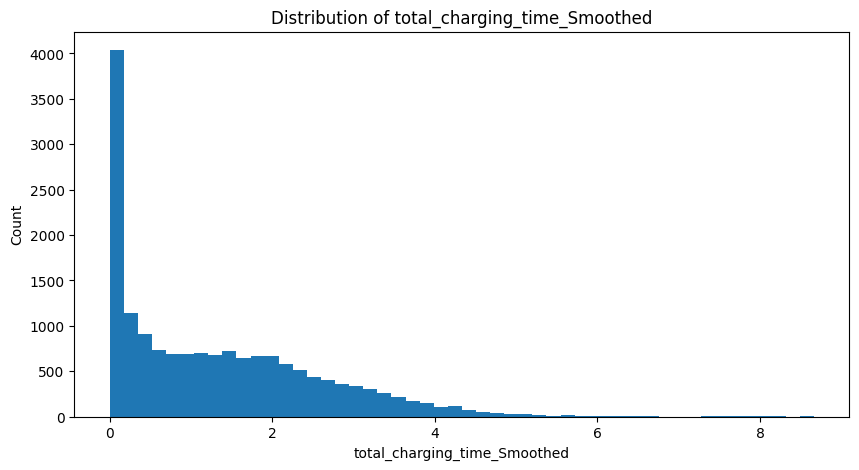

In [ ]:
plt.figure(figsize=(10, 5))
plt.hist(final_df_before_COVID_hourly['total_charging_time_Smoothed'], bins=50)
plt.xlabel('total_charging_time_Smoothed')
plt.ylabel('Count')
plt.title('Distribution of total_charging_time_Smoothed')
plt.show()

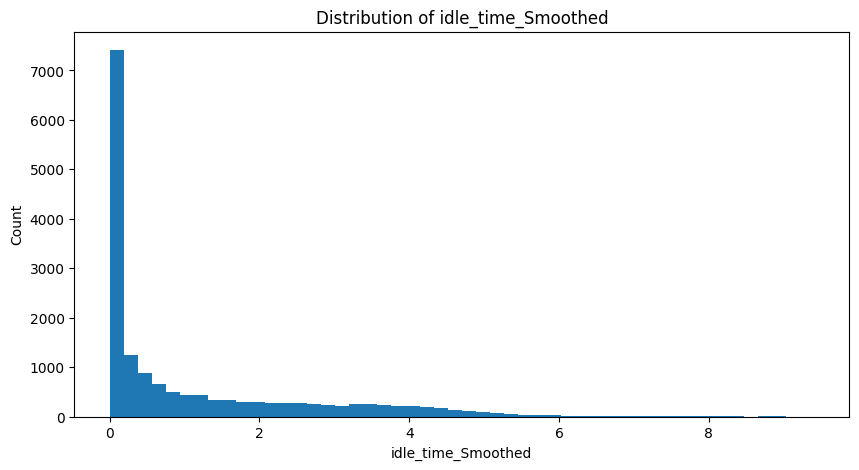

In [ ]:
plt.figure(figsize=(10, 5))
plt.hist(final_df_before_COVID_hourly['idle_time_Smoothed'], bins=50)
plt.xlabel('idle_time_Smoothed')
plt.ylabel('Count')
plt.title('Distribution of idle_time_Smoothed')
plt.show()

In [ ]:
final_df_before_COVID_hourly.columns.tolist()

['connectionTime',
 'siteID',
 'kWhDelivered',
 'total_charging_time',
 'idle_time',
 'kWhDelivered_Smoothed',
 'total_charging_time_Smoothed',
 'idle_time_Smoothed']

In [ ]:
final_df_before_COVID_hourly

,connectionTime,siteID,kWhDelivered,total_charging_time,idle_time,kWhDelivered_Smoothed,total_charging_time_Smoothed,idle_time_Smoothed
0,2018-04-25 06:00:00,2,7.635000,2.041528,8.208611,7.635000,2.041528,8.208611
1,2018-04-25 07:00:00,2,9.090600,2.309667,4.900278,7.635000,2.041528,8.208611
2,2018-04-25 08:00:00,2,4.909000,2.333162,5.337115,9.090600,2.309667,4.900278
3,2018-04-25 09:00:00,2,9.384286,4.034881,3.302976,4.909000,2.333162,5.337115
4,2018-04-25 10:00:00,2,5.070000,2.254167,6.821667,9.384286,4.034881,3.302976
...,...,...,...,...,...,...,...,...
16543,2020-03-14 13:00:00,0,0.000000,0.000000,0.000000,1.346901,0.214020,0.034712
16544,2020-03-14 14:00:00,1,12.812000,1.994167,0.003611,0.673451,0.107010,0.017356
16545,2020-03-14 15:00:00,2,4.421000,1.493889,0.393056,6.606229,1.028249,0.001862
16546,2020-03-14 16:00:00,2,0.830000,0.504444,1.075278,3.350296,1.132090,0.297863


In [ ]:
final_df_before_COVID_hourly.describe()

,kWhDelivered,total_charging_time,idle_time,kWhDelivered_Smoothed,total_charging_time_Smoothed,idle_time_Smoothed
count,16548.000000,16548.000000,16548.000000,1.654800e+04,1.654800e+04,1.654800e+04
mean,4.723003,1.366225,1.186878,4.635299e+00,1.320660e+00,1.104303e+00
std,5.124892,1.513426,1.832704,4.249546e+00,1.240238e+00,1.512346e+00
min,0.000000,0.000000,0.000000,3.825163e-12,1.024723e-12,1.285947e-12
25%,0.000000,0.000000,0.000000,6.392667e-01,1.863236e-01,2.703755e-03
50%,3.650250,1.057917,0.002500,3.890805e+00,1.057803e+00,3.063028e-01
75%,8.625637,2.364606,1.902465,7.608380e+00,2.122237e+00,1.801953e+00
max,33.167000,9.242500,11.927500,3.166176e+01,8.666005e+00,9.405849e+00


# Save the preprocessed Dataframe

In [ ]:
file_path = '../../../data/preprocessed/ACN/acn_caltech_jpl_0.2_0.1.22_06_2023.csv'
final_df_before_COVID_hourly.to_csv(file_path, index=False)